# KLUE/RoBERTa v4 - Cross Validation + Length/Epoch

v4는 v3의 class weight를 유지하고 다음을 추가합니다.

- `MAX_LENGTH = 384`
- `MAX_EPOCHS = 8`
- `PATIENCE = 2`
- `3-fold Stratified Cross Validation`

cross validation으로 train 구간 내부 평가 안정성을 확인한 뒤, fold별 best epoch 평균을 사용해 전체 train 데이터로 최종 모델을 학습합니다.

In [3]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
if device.type == 'cuda':
    print('gpu:', torch.cuda.get_device_name(0))

device: cuda
gpu: Tesla T4


## 1. Google Drive 연결

In [4]:
from google.colab import drive
drive.mount('/content/data')

Mounted at /content/data


## 2. 라이브러리 설치

In [5]:
!pip install -q transformers accelerate scikit-learn

## 3. 경로 및 기본 설정

In [6]:
from pathlib import Path

BASE_DIR = Path('/content/data/MyDrive/Final_project')
COMMON_DIR = BASE_DIR / 'common'
SPLIT_DIR = COMMON_DIR / 'split_v1'
RESULT_DIR = COMMON_DIR / 'klue_roberta_v4'

TRAIN_JSON = SPLIT_DIR / 'train_features_v1.json'
PREDICT_JSON = SPLIT_DIR / 'predict_input_v1.json'
ANSWER_JSON = SPLIT_DIR / 'test_answer_v1.json'

RESULT_JSON = RESULT_DIR / 'klue_roberta_v4_results.json'
RESULT_MD = RESULT_DIR / 'klue_roberta_v4_results.md'

MODEL_NAME = 'klue/roberta-base'
TARGET_COLUMNS = ['era', 'topic', 'question_type']

for path in [TRAIN_JSON, PREDICT_JSON, ANSWER_JSON]:
    print(path.name, 'exists =', path.exists())

train_features_v1.json exists = True
predict_input_v1.json exists = True
test_answer_v1.json exists = True


## 4. 실험 파라미터

In [7]:
import csv
import gc
import json
import random
from collections import Counter
from statistics import mean
from typing import Any

import numpy as np
import torch
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import StratifiedKFold
from torch.utils.data import DataLoader, Dataset
from transformers import AutoModelForSequenceClassification, AutoTokenizer, get_linear_schedule_with_warmup

MAX_LENGTH = 384
MAX_EPOCHS = 8
BATCH_SIZE = 8
LEARNING_RATE = 2e-5
PATIENCE = 2
MIN_DELTA = 0.0
N_SPLITS = 3
RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

## 5. 데이터 로드

In [8]:
def read_json(path: Path) -> Any:
    return json.loads(path.read_text(encoding='utf-8'))


train_rows = read_json(TRAIN_JSON)
predict_rows = read_json(PREDICT_JSON)
answer_rows = read_json(ANSWER_JSON)

print('train rows:', len(train_rows))
print('predict rows:', len(predict_rows))
print('answer rows:', len(answer_rows))

train rows: 1200
predict rows: 400
answer rows: 400


## 6. Dataset

In [9]:
class HanDataset(Dataset):
    def __init__(self, rows, tokenizer, label_to_id=None, target=None, max_length=384):
        self.rows = rows
        self.tokenizer = tokenizer
        self.label_to_id = label_to_id
        self.target = target
        self.max_length = max_length

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        row = self.rows[idx]
        text = str(row.get('text') or '')
        encoded = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt',
        )
        item = {key: value.squeeze(0) for key, value in encoded.items()}
        if self.label_to_id is not None and self.target is not None:
            item['labels'] = torch.tensor(self.label_to_id[str(row[self.target])], dtype=torch.long)
        return item

## 7. 평가/학습 함수

In [10]:
def make_label_maps(rows, target):
    labels = sorted(set(str(row[target]) for row in rows))
    label_to_id = {label: idx for idx, label in enumerate(labels)}
    id_to_label = {idx: label for label, idx in label_to_id.items()}
    return label_to_id, id_to_label


def make_class_weight_tensor(rows, target, label_to_id):
    counts = Counter(str(row[target]) for row in rows)
    total = sum(counts.values())
    num_classes = len(label_to_id)
    weights = [0.0] * num_classes
    for label, label_id in label_to_id.items():
        weights[label_id] = total / (num_classes * counts[label])
    return torch.tensor(weights, dtype=torch.float, device=device)


def evaluate_predictions(y_true, y_pred):
    return {
        'accuracy': round(float(accuracy_score(y_true, y_pred)), 6),
        'macro_f1': round(float(f1_score(y_true, y_pred, average='macro', zero_division=0)), 6),
        'weighted_f1': round(float(f1_score(y_true, y_pred, average='weighted', zero_division=0)), 6),
        'classification_report': classification_report(y_true, y_pred, output_dict=True, zero_division=0),
    }


def build_confusion_matrix(y_true, y_pred):
    labels = sorted(set(y_true) | set(y_pred))
    matrix = confusion_matrix(y_true, y_pred, labels=labels)
    return {
        'labels': labels,
        'matrix': matrix.astype(int).tolist(),
    }


def run_validation(model, valid_loader, loss_fn, id_to_label):
    model.eval()
    total_loss = 0.0
    y_true = []
    y_pred = []
    with torch.no_grad():
        for batch in valid_loader:
            batch = {key: value.to(device) for key, value in batch.items()}
            labels = batch.pop('labels')
            outputs = model(**batch)
            loss = loss_fn(outputs.logits, labels)
            total_loss += loss.item()
            y_true.extend(labels.cpu().tolist())
            y_pred.extend(outputs.logits.argmax(dim=-1).cpu().tolist())

    true_labels = [id_to_label[item] for item in y_true]
    pred_labels = [id_to_label[item] for item in y_pred]
    return total_loss / max(1, len(valid_loader)), evaluate_predictions(true_labels, pred_labels)


def cleanup_model(model):
    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

## 8. Fold 학습 함수

In [11]:
def train_fold(target, fold_no, fit_rows, valid_rows, tokenizer, label_to_id, id_to_label):
    print(f'\n[{target}] fold {fold_no}')
    fit_dataset = HanDataset(fit_rows, tokenizer, label_to_id, target, MAX_LENGTH)
    valid_dataset = HanDataset(valid_rows, tokenizer, label_to_id, target, MAX_LENGTH)
    fit_loader = DataLoader(fit_dataset, batch_size=BATCH_SIZE, shuffle=True)
    valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)

    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=len(label_to_id),
        id2label=id_to_label,
        label2id=label_to_id,
    ).to(device)

    class_weights = make_class_weight_tensor(fit_rows, target, label_to_id)
    loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
    total_steps = len(fit_loader) * MAX_EPOCHS
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=max(1, int(total_steps * 0.1)),
        num_training_steps=total_steps,
    )

    best_val_loss = float('inf')
    best_epoch = 0
    best_metrics = None
    patience_count = 0
    history = []

    for epoch in range(MAX_EPOCHS):
        model.train()
        train_loss = 0.0
        for batch in fit_loader:
            batch = {key: value.to(device) for key, value in batch.items()}
            labels = batch.pop('labels')
            optimizer.zero_grad()
            outputs = model(**batch)
            loss = loss_fn(outputs.logits, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            train_loss += loss.item()

        avg_train_loss = train_loss / max(1, len(fit_loader))
        val_loss, val_metrics = run_validation(model, valid_loader, loss_fn, id_to_label)
        history.append({
            'epoch': epoch + 1,
            'train_loss': round(float(avg_train_loss), 6),
            'val_loss': round(float(val_loss), 6),
            'val_macro_f1': val_metrics['macro_f1'],
        })
        print(f'epoch {epoch + 1}/{MAX_EPOCHS} train_loss={avg_train_loss:.4f} val_loss={val_loss:.4f} macro_f1={val_metrics["macro_f1"]:.4f}')

        if val_loss < best_val_loss - MIN_DELTA:
            best_val_loss = val_loss
            best_epoch = epoch + 1
            best_metrics = val_metrics
            patience_count = 0
        else:
            patience_count += 1
            print(f'no improvement: {patience_count}/{PATIENCE}')
            if patience_count >= PATIENCE:
                print(f'early stopping at epoch {epoch + 1}, best epoch = {best_epoch}')
                break

    cleanup_model(model)
    return {
        'fold': fold_no,
        'fit_size': len(fit_rows),
        'valid_size': len(valid_rows),
        'best_epoch': best_epoch,
        'best_val_loss': round(float(best_val_loss), 6),
        'best_metrics': best_metrics,
        'history': history,
    }

## 9. 전체 train 재학습 및 예측

In [12]:
def train_final_and_predict(target, final_epochs, tokenizer, label_to_id, id_to_label):
    print(f'\n[{target}] final train epochs = {final_epochs}')
    train_dataset = HanDataset(train_rows, tokenizer, label_to_id, target, MAX_LENGTH)
    predict_dataset = HanDataset(predict_rows, tokenizer, None, None, MAX_LENGTH)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    predict_loader = DataLoader(predict_dataset, batch_size=BATCH_SIZE, shuffle=False)

    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=len(label_to_id),
        id2label=id_to_label,
        label2id=label_to_id,
    ).to(device)

    class_weights = make_class_weight_tensor(train_rows, target, label_to_id)
    loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
    total_steps = len(train_loader) * final_epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=max(1, int(total_steps * 0.1)),
        num_training_steps=total_steps,
    )

    final_history = []
    for epoch in range(final_epochs):
        model.train()
        train_loss = 0.0
        for batch in train_loader:
            batch = {key: value.to(device) for key, value in batch.items()}
            labels = batch.pop('labels')
            optimizer.zero_grad()
            outputs = model(**batch)
            loss = loss_fn(outputs.logits, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            train_loss += loss.item()
        avg_train_loss = train_loss / max(1, len(train_loader))
        final_history.append({'epoch': epoch + 1, 'train_loss': round(float(avg_train_loss), 6)})
        print(f'final epoch {epoch + 1}/{final_epochs} train_loss={avg_train_loss:.4f}')

    pred_ids = []
    model.eval()
    with torch.no_grad():
        for batch in predict_loader:
            batch = {key: value.to(device) for key, value in batch.items()}
            outputs = model(**batch)
            pred_ids.extend(outputs.logits.argmax(dim=-1).cpu().tolist())

    y_pred = [id_to_label[pred_id] for pred_id in pred_ids]
    y_true = [str(row[target]) for row in answer_rows]
    metrics = evaluate_predictions(y_true, y_pred)
    row_predictions = []
    for pred_row, answer_row, true_label, pred_label in zip(predict_rows, answer_rows, y_true, y_pred):
        row_predictions.append({
            'round_no': pred_row.get('round_no'),
            'question_no': pred_row.get('question_no'),
            'problem_id': pred_row.get('problem_id'),
            'true_label': true_label,
            'pred_label': pred_label,
            'is_correct': true_label == pred_label,
            'text': pred_row.get('text'),
        })

    cleanup_model(model)
    return {
        'final_epochs': final_epochs,
        'class_weights': {id_to_label[i]: round(float(class_weights[i].cpu()), 6) for i in range(len(id_to_label))},
        'final_history': final_history,
        'test_metrics': metrics,
        'test_counts': dict(Counter(y_true).most_common()),
        'pred_counts': dict(Counter(y_pred).most_common()),
        'confusion_matrix': build_confusion_matrix(y_true, y_pred),
        'row_predictions': row_predictions,
    }

## 10. Target별 Cross Validation 실행

In [13]:
def run_target(target):
    print(f'\n===== target: {target} =====')
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    label_to_id, id_to_label = make_label_maps(train_rows, target)
    labels = np.array([str(row[target]) for row in train_rows])
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

    folds = []
    for fold_no, (fit_idx, valid_idx) in enumerate(skf.split(np.zeros(len(labels)), labels), start=1):
        fit_rows = [train_rows[idx] for idx in fit_idx]
        valid_rows = [train_rows[idx] for idx in valid_idx]
        folds.append(train_fold(target, fold_no, fit_rows, valid_rows, tokenizer, label_to_id, id_to_label))

    best_epochs = [fold['best_epoch'] for fold in folds if fold['best_epoch']]
    final_epochs = max(1, int(round(mean(best_epochs)))) if best_epochs else MAX_EPOCHS
    final_result = train_final_and_predict(target, final_epochs, tokenizer, label_to_id, id_to_label)

    fold_macro_f1 = [fold['best_metrics']['macro_f1'] for fold in folds]
    fold_accuracy = [fold['best_metrics']['accuracy'] for fold in folds]
    return {
        'label_count': len(label_to_id),
        'train_counts': dict(Counter(labels).most_common()),
        'folds': folds,
        'cv_summary': {
            'mean_accuracy': round(float(mean(fold_accuracy)), 6),
            'mean_macro_f1': round(float(mean(fold_macro_f1)), 6),
            'mean_best_epoch': round(float(mean(best_epochs)), 3),
            'final_epochs': final_epochs,
        },
        **final_result,
    }


results = {
    'experiment': 'klue_roberta_v4_cross_validation_length_epoch',
    'model_name': MODEL_NAME,
    'class_weight': True,
    'cross_validation': True,
    'n_splits': N_SPLITS,
    'max_length': MAX_LENGTH,
    'max_epochs': MAX_EPOCHS,
    'batch_size': BATCH_SIZE,
    'learning_rate': LEARNING_RATE,
    'patience': PATIENCE,
    'min_delta': MIN_DELTA,
    'targets': {},
}

results['targets']['era'] = run_target('era')
results['targets']['era']['test_metrics']


===== target: era =====


config.json:   0%|          | 0.00/546 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/375 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/248k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/752k [00:00<?, ?B/s]

...

epoch 1/8 train_loss=2.2606 val_loss=1.9241 macro_f1=0.2357
epoch 2/8 train_loss=1.5380 val_loss=1.2527 macro_f1=0.5818
epoch 3/8 train_loss=0.9395 val_loss=0.9883 macro_f1=0.7231
epoch 4/8 train_loss=0.6269 val_loss=0.9220 macro_f1=0.7189
epoch 5/8 train_loss=0.4034 val_loss=0.8914 macro_f1=0.7399
epoch 6/8 train_loss=0.2594 val_loss=0.9630 macro_f1=0.7140
no improvement: 1/2
epoch 7/8 train_loss=0.1896 val_loss=0.9954 macro_f1=0.7368
no improvement: 2/2
early stopping at epoch 7, best epoch = 5

[era] final train epochs = 4


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: klue/roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


final epoch 1/4 train_loss=1.9897
final epoch 2/4 train_loss=1.1253
final epoch 3/4 train_loss=0.7413
final epoch 4/4 train_loss=0.5226


{'accuracy': 0.7775,
 'macro_f1': 0.751374,
 'weighted_f1': 0.780075,
 'classification_report': {'개항기': {'precision': 0.6808510638297872,
   'recall': 0.8888888888888888,
   'f1-score': 0.7710843373493976,
   'support': 36.0},
  '고려': {'precision': 0.8333333333333334,
   'recall': 0.7258064516129032,
   'f1-score': 0.7758620689655172,
   'support': 62.0},
  '고조선': {'precision': 0.8333333333333334,
   'recall': 0.7142857142857143,
   'f1-score': 0.7692307692307693,
   'support': 7.0},
  '남북국 시대': {'precision': 0.5405405405405406,
   'recall': 0.625,
   'f1-score': 0.5797101449275363,
   'support': 32.0},
  '삼국 시대': {'precision': 0.7450980392156863,
   'recall': 0.8636363636363636,
   'f1-score': 0.8,
   'support': 44.0},
  '선사 시대': {'precision': 1.0,
   'recall': 0.75,
   'f1-score': 0.8571428571428571,
   'support': 8.0},
  '일제 강점기': {'precision': 0.8421052631578947,
   'recall': 0.7441860465116279,
   'f1-score': 0.7901234567901234,
   'support': 43.0},
  '조선': {'precision': 0.8909090

## 11. topic 실행

In [14]:
results['targets']['topic'] = run_target('topic')
results['targets']['topic']['test_metrics']


===== target: topic =====

[topic] fold 1


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: klue/roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


epoch 1/8 train_loss=2.2527 val_loss=2.1909 macro_f1=0.1108
epoch 2/8 train_loss=2.0484 val_loss=1.8128 macro_f1=0.2642
epoch 3/8 train_loss=1.5655 val_loss=1.5807 macro_f1=0.4494
epoch 4/8 train_loss=1.1467 val_loss=1.5464 macro_f1=0.4201
epoch 5/8 train_loss=0.8174 val_loss=1.5753 macro_f1=0.4261
no improvement: 1/2
epoch 6/8 train_loss=0.6186 val_loss=1.6055 macro_f1=0.3985
no improvement: 2/2
early stopping at epoch 6, best epoch = 4

[topic] fold 2


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

epoch 1/8 train_loss=2.2409 val_loss=2.2257 macro_f1=0.0801
epoch 2/8 train_loss=2.0730 val_loss=1.9378 macro_f1=0.2546
epoch 3/8 train_loss=1.6353 val_loss=1.6588 macro_f1=0.3577
epoch 4/8 train_loss=1.3294 val_loss=1.5261 macro_f1=0.4355
epoch 5/8 train_loss=0.9276 val_loss=1.5867 macro_f1=0.4120
no improvement: 1/2
epoch 6/8 train_loss=0.6550 val_loss=1.6790 macro_f1=0.3972
no improvement: 2/2
early stopping at epoch 6, best epoch = 4

[topic] final train epochs = 4


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: klue/roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


final epoch 1/4 train_loss=2.2280
final epoch 2/4 train_loss=1.7741
final epoch 3/4 train_loss=1.3234
final epoch 4/4 train_loss=0.9871


{'accuracy': 0.4175,
 'macro_f1': 0.350979,
 'weighted_f1': 0.396332,
 'classification_report': {'경제': {'precision': 0.2857142857142857,
   'recall': 0.25,
   'f1-score': 0.26666666666666666,
   'support': 16.0},
  '군사': {'precision': 0.3333333333333333,
   'recall': 0.15384615384615385,
   'f1-score': 0.21052631578947367,
   'support': 13.0},
  '문화': {'precision': 0.5471698113207547,
   'recall': 0.6744186046511628,
   'f1-score': 0.6041666666666666,
   'support': 43.0},
  '사건': {'precision': 0.4835164835164835,
   'recall': 0.5714285714285714,
   'f1-score': 0.5238095238095238,
   'support': 77.0},
  '사상·종교': {'precision': 0.6, 'recall': 0.3, 'f1-score': 0.4, 'support': 10.0},
  '사회': {'precision': 0.6666666666666666,
   'recall': 0.17391304347826086,
   'f1-score': 0.27586206896551724,
   'support': 23.0},
  '외교': {'precision': 0.5,
   'recall': 0.047619047619047616,
   'f1-score': 0.08695652173913043,
   'support': 21.0},
  '인물': {'precision': 0.4,
   'recall': 0.5063291139240507,


## 12. question_type 실행

In [15]:
results['targets']['question_type'] = run_target('question_type')
results['targets']['question_type']['test_metrics']


===== target: question_type =====

[question_type] fold 1


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: klue/roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


epoch 1/8 train_loss=1.5338 val_loss=1.3832 macro_f1=0.2414
epoch 2/8 train_loss=0.9545 val_loss=0.5656 macro_f1=0.7213
epoch 3/8 train_loss=0.4006 val_loss=0.7190 macro_f1=0.7236
no improvement: 1/2
epoch 4/8 train_loss=0.4128 val_loss=0.9999 macro_f1=0.6445
no improvement: 2/2
early stopping at epoch 4, best epoch = 2

[question_type] fold 2


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

epoch 1/8 train_loss=1.5108 val_loss=1.2874 macro_f1=0.4212
epoch 2/8 train_loss=0.7846 val_loss=0.5472 macro_f1=0.7103
epoch 3/8 train_loss=0.4027 val_loss=0.5942 macro_f1=0.7278
no improvement: 1/2
epoch 4/8 train_loss=0.3408 val_loss=0.4797 macro_f1=0.7838
epoch 5/8 train_loss=0.2251 val_loss=0.4317 macro_f1=0.8416
epoch 6/8 train_loss=0.0781 val_loss=0.3853 macro_f1=0.8649
epoch 7/8 train_loss=0.0477 val_loss=0.3692 macro_f1=0.8951
epoch 8/8 train_loss=0.0247 val_loss=0.3605 macro_f1=0.8718

[question_type] final train epochs = 6


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: klue/roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


final epoch 1/6 train_loss=1.4649
final epoch 2/6 train_loss=0.6836
final epoch 3/6 train_loss=0.4190
final epoch 4/6 train_loss=0.2872
final epoch 5/6 train_loss=0.1290
final epoch 6/6 train_loss=0.0493


{'accuracy': 0.775,
 'macro_f1': 0.371843,
 'weighted_f1': 0.838018,
 'classification_report': {'역사 자료의 분석 및 해석': {'precision': 0.9893617021276596,
   'recall': 0.7622950819672131,
   'f1-score': 0.8611111111111112,
   'support': 366.0},
  '역사 지식의 이해': {'precision': 0.0,
   'recall': 0.0,
   'f1-score': 0.0,
   'support': 0.0},
  '역사 탐구의 설계 및 수행': {'precision': 0.0,
   'recall': 0.0,
   'f1-score': 0.0,
   'support': 2.0},
  '연대기의 파악': {'precision': 0.4626865671641791,
   'recall': 0.96875,
   'f1-score': 0.6262626262626263,
   'support': 32.0},
  'accuracy': 0.775,
  'macro avg': {'precision': 0.36301206732295965,
   'recall': 0.43276127049180324,
   'f1-score': 0.37184343434343436,
   'support': 400.0},
  'weighted avg': {'precision': 0.9422808828199429,
   'recall': 0.775,
   'f1-score': 0.8380176767676768,
   'support': 400.0}}}

## 13. 요약

In [16]:
summary = {
    target: {
        'cv_mean_macro_f1': results['targets'][target]['cv_summary']['mean_macro_f1'],
        'final_epochs': results['targets'][target]['cv_summary']['final_epochs'],
        'test_accuracy': results['targets'][target]['test_metrics']['accuracy'],
        'test_macro_f1': results['targets'][target]['test_metrics']['macro_f1'],
        'test_weighted_f1': results['targets'][target]['test_metrics']['weighted_f1'],
    }
    for target in TARGET_COLUMNS
}
summary

{'era': {'cv_mean_macro_f1': 0.725869,
  'final_epochs': 4,
  'test_accuracy': 0.7775,
  'test_macro_f1': 0.751374,
  'test_weighted_f1': 0.780075},
 'topic': {'cv_mean_macro_f1': 0.406019,
  'final_epochs': 4,
  'test_accuracy': 0.4175,
  'test_macro_f1': 0.350979,
  'test_weighted_f1': 0.396332},
 'question_type': {'cv_mean_macro_f1': 0.806161,
  'final_epochs': 6,
  'test_accuracy': 0.775,
  'test_macro_f1': 0.371843,
  'test_weighted_f1': 0.838018}}

## 14. Final Loss / Confusion Matrix 그래프

v3에서 추가했던 그래프 확인 기능을 v4에도 유지합니다.
한글 라벨이 깨지지 않도록 `koreanize-matplotlib`을 먼저 적용하고, 필요하면 NanumGothic을 fallback으로 설정합니다.

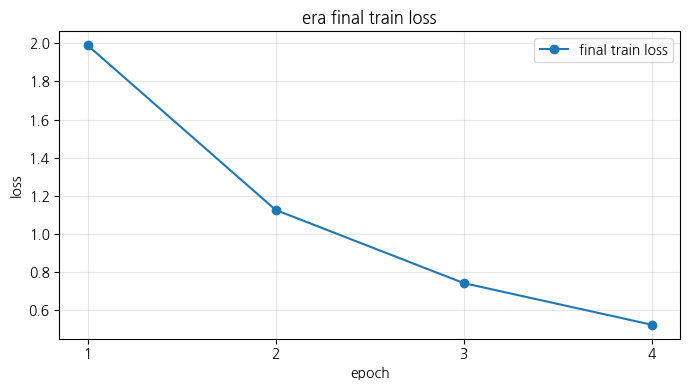

saved loss graph: /content/data/MyDrive/Final_project/common/klue_roberta_v4/era_klue_roberta_v4_loss.png


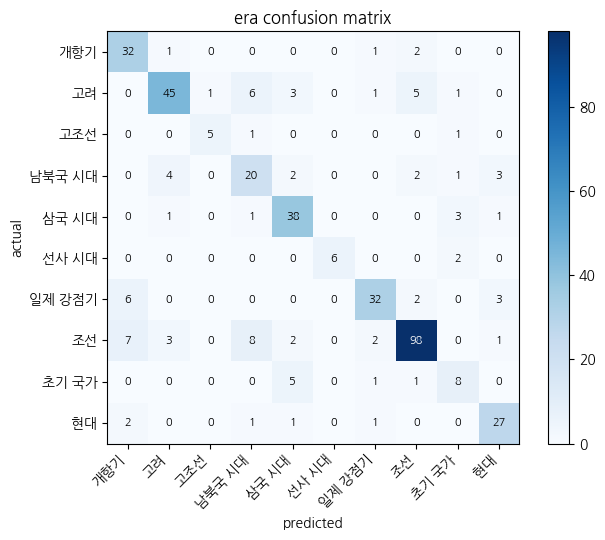

saved confusion matrix: /content/data/MyDrive/Final_project/common/klue_roberta_v4/era_klue_roberta_v4_confusion_matrix.png


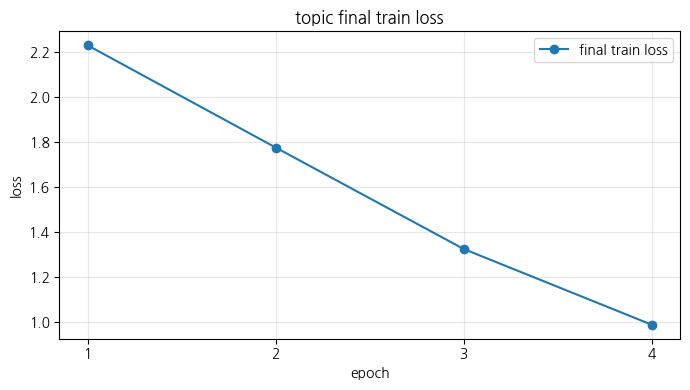

saved loss graph: /content/data/MyDrive/Final_project/common/klue_roberta_v4/topic_klue_roberta_v4_loss.png


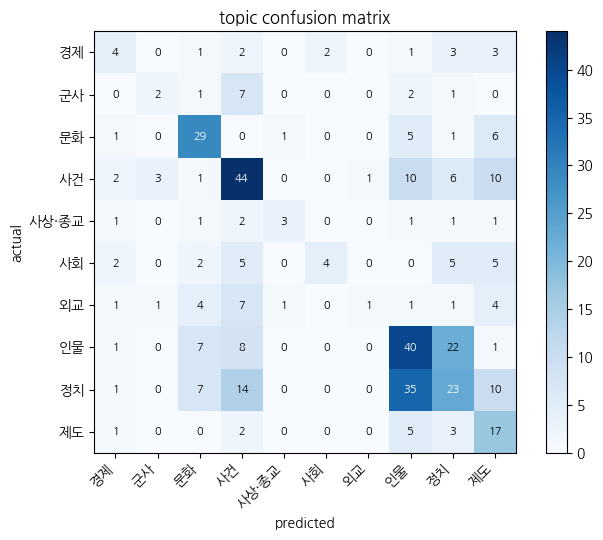

saved confusion matrix: /content/data/MyDrive/Final_project/common/klue_roberta_v4/topic_klue_roberta_v4_confusion_matrix.png


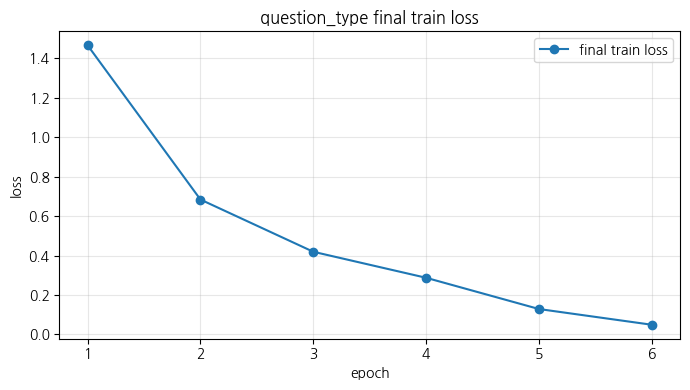

saved loss graph: /content/data/MyDrive/Final_project/common/klue_roberta_v4/question_type_klue_roberta_v4_loss.png


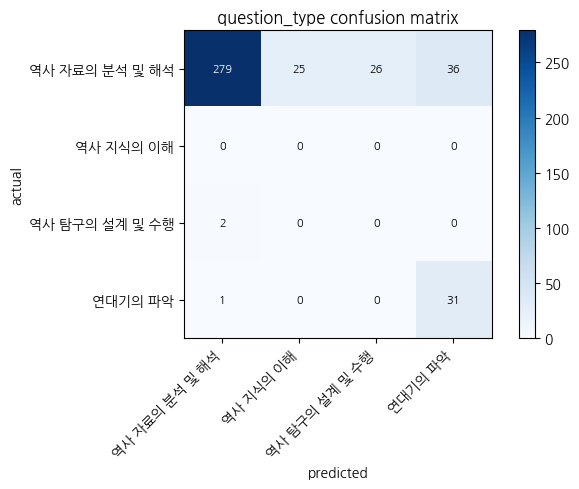

saved confusion matrix: /content/data/MyDrive/Final_project/common/klue_roberta_v4/question_type_klue_roberta_v4_confusion_matrix.png


In [17]:
import subprocess

import matplotlib.pyplot as plt
from matplotlib import font_manager

RESULT_DIR.mkdir(parents=True, exist_ok=True)

try:
    import koreanize_matplotlib
except ImportError:
    subprocess.run(['pip', 'install', '-q', 'koreanize-matplotlib'], check=False)
    import koreanize_matplotlib

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
if 'NanumGothic' not in plt.rcParams.get('font.family', []):
    if not Path(font_path).exists():
        subprocess.run(['apt-get', 'update', '-qq'], check=False)
        subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], check=False)
    if Path(font_path).exists():
        font_manager.fontManager.addfont(font_path)
        plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

for target in TARGET_COLUMNS:
    target_result = results['targets'][target]

    final_history = target_result.get('final_history', [])
    if final_history:
        epochs = [item['epoch'] for item in final_history]
        train_losses = [item['train_loss'] for item in final_history]
        plt.figure(figsize=(7, 4))
        plt.plot(epochs, train_losses, marker='o', label='final train loss')
        plt.title(f'{target} final train loss')
        plt.xlabel('epoch')
        plt.ylabel('loss')
        plt.xticks(epochs)
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        loss_png = RESULT_DIR / f'{target}_klue_roberta_v4_loss.png'
        plt.savefig(loss_png, dpi=150)
        plt.show()
        print('saved loss graph:', loss_png)

    cm = target_result.get('confusion_matrix')
    if cm is None and target_result.get('row_predictions'):
        y_true_for_cm = [row['true_label'] for row in target_result['row_predictions']]
        y_pred_for_cm = [row['pred_label'] for row in target_result['row_predictions']]
        cm = build_confusion_matrix(y_true_for_cm, y_pred_for_cm)
        target_result['confusion_matrix'] = cm

    if cm:
        labels = cm['labels']
        matrix = np.array(cm['matrix'])
        plt.figure(figsize=(max(7, len(labels) * 0.7), max(5, len(labels) * 0.55)))
        plt.imshow(matrix, cmap='Blues')
        plt.title(f'{target} confusion matrix')
        plt.xlabel('predicted')
        plt.ylabel('actual')
        plt.xticks(range(len(labels)), labels, rotation=45, ha='right')
        plt.yticks(range(len(labels)), labels)
        plt.colorbar()

        max_value = matrix.max() if matrix.size else 0
        threshold = max_value / 2 if max_value else 0
        for row_idx in range(matrix.shape[0]):
            for col_idx in range(matrix.shape[1]):
                value = matrix[row_idx, col_idx]
                color = 'white' if value > threshold else 'black'
                plt.text(col_idx, row_idx, str(value), ha='center', va='center', color=color, fontsize=8)

        plt.tight_layout()
        cm_png = RESULT_DIR / f'{target}_klue_roberta_v4_confusion_matrix.png'
        plt.savefig(cm_png, dpi=150)
        plt.show()
        print('saved confusion matrix:', cm_png)

## 15. Markdown 리포트 생성

In [18]:
def build_markdown(results):
    lines = []
    lines.append('# KLUE/RoBERTa v4 Results - Cross Validation')
    lines.append('')
    lines.append('- Model: `klue/roberta-base`')
    lines.append('- Class weight: applied')
    lines.append(f'- N splits: {results["n_splits"]}')
    lines.append(f'- Max length: {results["max_length"]}')
    lines.append(f'- Max epochs: {results["max_epochs"]}')
    lines.append(f'- Patience: {results["patience"]}')
    lines.append('')
    lines.append('## Summary')
    lines.append('')
    lines.append('| target | cv mean accuracy | cv mean macro_f1 | final_epochs | test accuracy | test macro_f1 | test weighted_f1 |')
    lines.append('|---|---:|---:|---:|---:|---:|---:|')
    for target in TARGET_COLUMNS:
        item = results['targets'][target]
        cv = item['cv_summary']
        test = item['test_metrics']
        lines.append(
            f"| {target} | {cv['mean_accuracy']:.4f} | {cv['mean_macro_f1']:.4f} | {cv['final_epochs']} | "
            f"{test['accuracy']:.4f} | {test['macro_f1']:.4f} | {test['weighted_f1']:.4f} |"
        )
    lines.append('')

    for target in TARGET_COLUMNS:
        item = results['targets'][target]
        lines.append(f'## {target}')
        lines.append('')
        lines.append('### Fold Results')
        lines.append('')
        lines.append('| fold | best_epoch | best_val_loss | accuracy | macro_f1 | weighted_f1 |')
        lines.append('|---:|---:|---:|---:|---:|---:|')
        for fold in item['folds']:
            metrics = fold['best_metrics']
            lines.append(
                f"| {fold['fold']} | {fold['best_epoch']} | {fold['best_val_loss']:.4f} | "
                f"{metrics['accuracy']:.4f} | {metrics['macro_f1']:.4f} | {metrics['weighted_f1']:.4f} |"
            )
        lines.append('')
        lines.append('### Final Train Loss')
        lines.append('')
        lines.append('| epoch | train_loss |')
        lines.append('|---:|---:|')
        for row in item.get('final_history', []):
            lines.append(f"| {row['epoch']} | {row['train_loss']:.4f} |")
        lines.append('')
        lines.append('### Class Weights')
        lines.append('')
        lines.append('| label | weight |')
        lines.append('|---|---:|')
        for label, weight in item.get('class_weights', {}).items():
            lines.append(f'| {label} | {weight:.4f} |')
        lines.append('')
        lines.append('### Test Per-class Metrics')
        lines.append('')
        lines.append('| label | precision | recall | f1-score | support |')
        lines.append('|---|---:|---:|---:|---:|')
        report = item['test_metrics']['classification_report']
        labels = sorted(set(item['test_counts']) | set(item['pred_counts']) | set(item['train_counts']))
        for label in labels:
            values = report.get(label, {})
            lines.append(
                f"| {label} | {values.get('precision', 0):.4f} | {values.get('recall', 0):.4f} | "
                f"{values.get('f1-score', 0):.4f} | {int(values.get('support', 0))} |"
            )
        lines.append('')
        lines.append('### Confusion Matrix')
        lines.append('')
        cm = item.get('confusion_matrix')
        if cm is None and item.get('row_predictions'):
            y_true_for_cm = [row['true_label'] for row in item['row_predictions']]
            y_pred_for_cm = [row['pred_label'] for row in item['row_predictions']]
            cm = build_confusion_matrix(y_true_for_cm, y_pred_for_cm)
        if cm:
            cm_labels = cm['labels']
            lines.append('| actual \\ predicted | ' + ' | '.join(cm_labels) + ' |')
            lines.append('|---|' + '|'.join(['---:'] * len(cm_labels)) + '|')
            for label, row in zip(cm_labels, cm['matrix']):
                lines.append(f'| {label} | ' + ' | '.join(str(value) for value in row) + ' |')
        else:
            lines.append('Confusion matrix is not available.')
        lines.append('')
    return '\n'.join(lines) + '\n'

## 15. 결과 저장

In [19]:
RESULT_DIR.mkdir(parents=True, exist_ok=True)
RESULT_JSON.write_text(json.dumps(results, ensure_ascii=False, indent=2) + '\n', encoding='utf-8')
RESULT_MD.write_text(build_markdown(results), encoding='utf-8')

for target in TARGET_COLUMNS:
    pred_csv = RESULT_DIR / f'{target}_klue_roberta_v4_predictions.csv'
    with pred_csv.open('w', encoding='utf-8-sig', newline='') as file:
        writer = csv.DictWriter(
            file,
            fieldnames=['round_no', 'question_no', 'problem_id', 'true_label', 'pred_label', 'is_correct', 'text'],
        )
        writer.writeheader()
        writer.writerows(results['targets'][target]['row_predictions'])
    print('saved predictions:', pred_csv)

print('saved result json:', RESULT_JSON)
print('saved result md:', RESULT_MD)

saved predictions: /content/data/MyDrive/Final_project/common/klue_roberta_v4/era_klue_roberta_v4_predictions.csv
saved predictions: /content/data/MyDrive/Final_project/common/klue_roberta_v4/topic_klue_roberta_v4_predictions.csv
saved predictions: /content/data/MyDrive/Final_project/common/klue_roberta_v4/question_type_klue_roberta_v4_predictions.csv
saved result json: /content/data/MyDrive/Final_project/common/klue_roberta_v4/klue_roberta_v4_results.json
saved result md: /content/data/MyDrive/Final_project/common/klue_roberta_v4/klue_roberta_v4_results.md


## 16. 저장된 결과 확인

In [20]:
print(RESULT_MD.read_text(encoding='utf-8')[:5000])

# KLUE/RoBERTa v4 Results - Cross Validation

- Model: `klue/roberta-base`
- Class weight: applied
- N splits: 3
- Max length: 384
- Max epochs: 8
- Patience: 2

## Summary

| target | cv mean accuracy | cv mean macro_f1 | final_epochs | test accuracy | test macro_f1 | test weighted_f1 |
|---|---:|---:|---:|---:|---:|---:|
| era | 0.7508 | 0.7259 | 4 | 0.7775 | 0.7514 | 0.7801 |
| topic | 0.5767 | 0.4060 | 4 | 0.4175 | 0.3510 | 0.3963 |
| question_type | 0.9267 | 0.8062 | 6 | 0.7750 | 0.3718 | 0.8380 |

## era

### Fold Results

| fold | best_epoch | best_val_loss | accuracy | macro_f1 | weighted_f1 |
|---:|---:|---:|---:|---:|---:|
| 1 | 3 | 1.0739 | 0.7375 | 0.6707 | 0.7364 |
| 2 | 5 | 0.9039 | 0.7525 | 0.7670 | 0.7559 |
| 3 | 5 | 0.8914 | 0.7625 | 0.7399 | 0.7603 |

### Final Train Loss

| epoch | train_loss |
|---:|---:|
| 1 | 1.9897 |
| 2 | 1.1253 |
| 3 | 0.7413 |
| 4 | 0.5226 |

### Class Weights

| label | weight |
|---|---:|
| 개항기 | 0.9449 |
| 고려 | 0.6897 |
| 고조선 | 6.0000 |
| 남